## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#f9f9f9',
    'axes.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False
})
print("All libraries imported successfully")

All libraries imported successfully


## Step 2 — Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\ritik\OneDrive\Desktop\Pbl.data.csv")   # ← update path if needed

df.head(10)


,Customer_ID,Age,Gender,Region,Platform,Membership_Type,Annual_Spending,Purchase_Frequency,Returns_Count,Online_Purchase_Ratio,Preferred_Payment_Method,Customer_Tenure_Months
0,1522.0,28.0,Male,Central,Flipkart,Platinum,43444.30,24.0,3.0,0.53,Cash,56.0
1,1738.0,46.0,Female,West,NaN,NaN,NaN,10.0,2.0,0.15,Credit Card,18.0
2,1741.0,46.0,Female,West,NaN,Platinum,30250.27,30.0,NaN,0.55,Digital Wallet,29.0
3,1661.0,46.0,Female,West,Croma,Platinum,38433.06,19.0,2.0,0.32,NaN,24.0
4,1412.0,NaN,Male,NaN,Croma,Silver,5999.76,11.0,0.0,0.75,Cash,NaN
5,1679.0,44.0,Female,NaN,AJIO,Gold,NaN,3.0,NaN,NaN,Debit Card,28.0
6,1627.0,45.0,NaN,North,Flipkart,Gold,NaN,33.0,1.0,0.46,Digital Wallet,13.0
7,1514.0,51.0,Male,West,Croma,NaN,7329.41,6.0,1.0,0.53,Digital Wallet,25.0
8,1860.0,32.0,Male,West,Meesho,Platinum,70140.48,40.0,3.0,0.69,Debit Card,65.0
9,1137.0,34.0,Male,East,Flipkart,Gold,35709.26,25.0,0.0,0.33,Credit Card,41.0


In [3]:
df.shape

(1000, 12)

## Step 3 — Exploratory Data Analysis

In [4]:
df.info()
print()
print("=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(missing_df[missing_df['Missing Count'] > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               850 non-null    float64
 1   Age                       850 non-null    float64
 2   Gender                    850 non-null    object 
 3   Region                    850 non-null    object 
 4   Platform                  850 non-null    object 
 5   Membership_Type           850 non-null    object 
 6   Annual_Spending           850 non-null    float64
 7   Purchase_Frequency        850 non-null    float64
 8   Returns_Count             850 non-null    float64
 9   Online_Purchase_Ratio     850 non-null    float64
 10  Preferred_Payment_Method  850 non-null    object 
 11  Customer_Tenure_Months    850 non-null    float64
dtypes: float64(7), object(5)
memory usage: 93.9+ KB

MISSING VALUES PER COLUMN
                          Missing Count  Mis

In [5]:
print("DESCRIPTIVE STATISTICS — Numeric Columns")
df.describe().round(2)

DESCRIPTIVE STATISTICS — Numeric Columns


,Customer_ID,Age,Annual_Spending,Purchase_Frequency,Returns_Count,Online_Purchase_Ratio,Customer_Tenure_Months
count,850.00,850.00,850.00,850.00,850.00,850.00,850.00
mean,1496.10,41.39,32006.84,21.82,1.50,0.46,33.21
std,288.97,14.26,32629.11,15.62,1.44,0.19,17.68
min,1001.00,18.00,190.61,1.00,0.00,0.10,3.00
25%,1243.50,29.00,1681.67,9.00,0.00,0.33,20.00
50%,1493.50,41.00,27751.79,17.00,1.00,0.46,31.00
75%,1747.50,53.00,45142.26,31.00,2.00,0.58,44.00
max,2000.00,67.00,133819.71,72.00,5.00,0.90,83.00


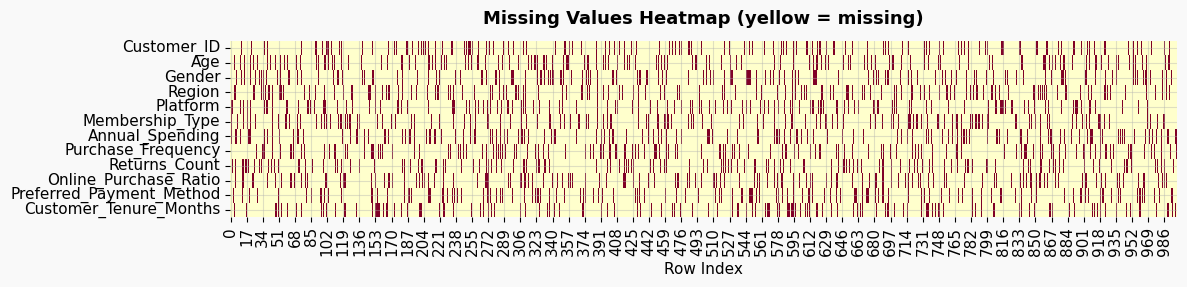

In [6]:
plt.figure(figsize=(12, 3))
sns.heatmap(df.isnull().T, cbar=False, cmap='YlOrRd', yticklabels=df.columns)
plt.title('Missing Values Heatmap (yellow = missing)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Row Index')
plt.tight_layout()
plt.show()

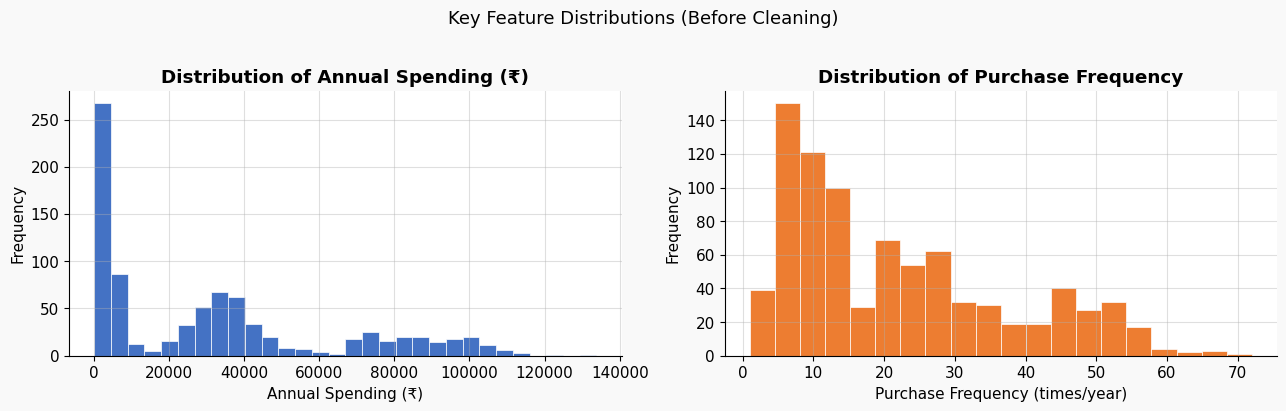

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Annual_Spending'].dropna(), bins=30, color='#4472C4', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Annual Spending (₹)', fontweight='bold')
axes[0].set_xlabel('Annual Spending (₹)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Purchase_Frequency'].dropna(), bins=20, color='#ED7D31', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribution of Purchase Frequency', fontweight='bold')
axes[1].set_xlabel('Purchase Frequency (times/year)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Key Feature Distributions (Before Cleaning)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("graph1", dpi=100, bbox_inches='tight')
plt.show()

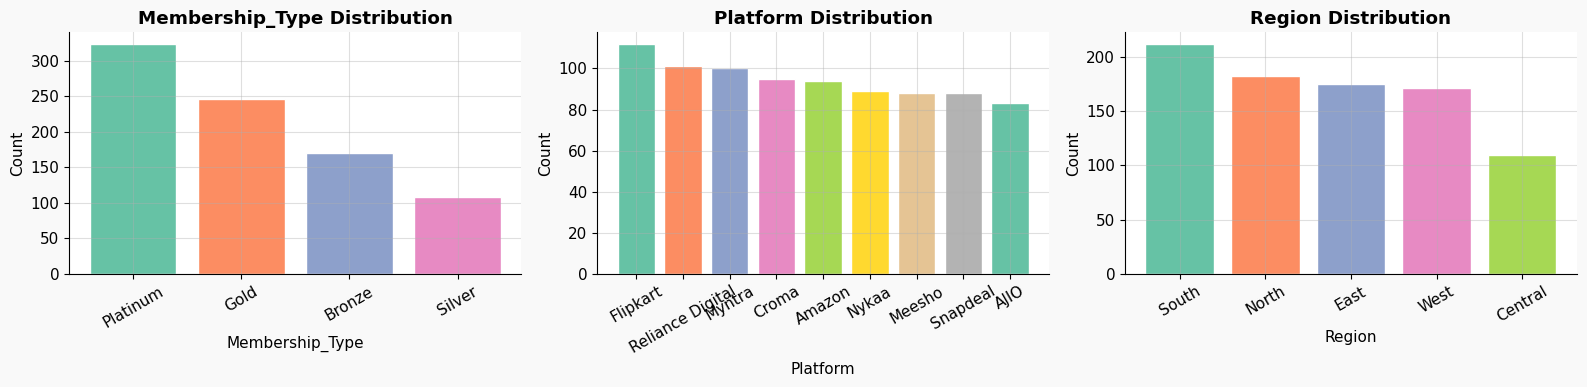

In [62]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = sns.color_palette("Set2", 10)

for ax, col in zip(axes, ['Membership_Type', 'Platform', 'Region']):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color=palette[:len(vc)], edgecolor='white')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
plt.savefig("plot2t.png", dpi=100, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Step 4 — Data Cleaning & Preprocessing

In [9]:
df.isnull().sum()

Customer_ID                 150
Age                         150
Gender                      150
Region                      150
Platform                    150
Membership_Type             150
Annual_Spending             150
Purchase_Frequency          150
Returns_Count               150
Online_Purchase_Ratio       150
Preferred_Payment_Method    150
Customer_Tenure_Months      150
dtype: int64

In [10]:
df1 = df.copy()

before = len(df1)
df1.dropna(subset=['Customer_ID'], inplace=True)
print(f"Rows dropped (missing Customer_ID): {before - len(df1)}")
print(f"Remaining rows: {len(df1)}")

Rows dropped (missing Customer_ID): 150
Remaining rows: 850


In [11]:
median_cols = ['Age', 
               'Annual_Spending', 
               'Purchase_Frequency',
               'Returns_Count', 
               'Customer_Tenure_Months']

for col in median_cols:
    median_val = df1[col].median()
    df1[col]=df1[col].fillna(median_val)
    print(f"{col} filled with median: {median_val:.2f}")
print("\n")

mean_val = df1['Online_Purchase_Ratio'].mean()
df1['Online_Purchase_Ratio']=df1['Online_Purchase_Ratio'].fillna(mean_val)
print(f"Online_Purchase_Ratio filled with mean: {mean_val:.2f}")

print("\n")

cat_cols = ['Gender', 
            'Region', 
            'Platform', 
            'Membership_Type',
            'Preferred_Payment_Method']

for col in cat_cols:
    mode_val = df1[col].mode()[0]
    df1[col] = df1[col].fillna(mode_val)
    print(f"{col} filled with mode: {mode_val}")
    
print(f"\n Null values after cleaning: {df1.isnull().sum().sum()}")

Age filled with median: 42.00
Annual_Spending filled with median: 27838.90
Purchase_Frequency filled with median: 17.00
Returns_Count filled with median: 1.00
Customer_Tenure_Months filled with median: 31.00


Online_Purchase_Ratio filled with mean: 0.46


Gender filled with mode: Female
Region filled with mode: South
Platform filled with mode: Flipkart
Membership_Type filled with mode: Platinum
Preferred_Payment_Method filled with mode: Credit Card

 Null values after cleaning: 0


## Step 5 — Label Encoding (Categorical → Numeric)

In [12]:
df1.loc[:, 'Gender'] = df1['Gender'].map({'Male': 0, 'Female': 1})
df1.loc[:, 'Region'] = df1['Region'].map({'East': 0, 'West': 1, 'North': 2, 'South': 3, 'Central': 4})
df1.loc[:, 'Platform'] = df1['Platform'].map({
    'Amazon': 0, 'Flipkart': 1, 'Snapdeal': 2,
    'Meesho': 3, 'Myntra': 4, 'AJIO': 5,
    'Nykaa': 6, 'Reliance Digital': 7, 'Croma': 8
})
df1.loc[:, 'Membership_Type'] = df1['Membership_Type'].map({
    'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3
})
df1.loc[:, 'Preferred_Payment_Method'] = df1['Preferred_Payment_Method'].map({
    'Credit Card': 0, 'Debit Card': 1,
    'Digital Wallet': 2, 'Cash': 3,
    'Buy Now Pay Later': 4
})

print(" Encoding complete")
print(f"\nDataFrame shape: {df1.shape}")
df1.head(5)

 Encoding complete

DataFrame shape: (850, 12)


,Customer_ID,Age,Gender,Region,Platform,Membership_Type,Annual_Spending,Purchase_Frequency,Returns_Count,Online_Purchase_Ratio,Preferred_Payment_Method,Customer_Tenure_Months
0,1522.0,28.0,0,4,1,3,43444.30,24.0,3.0,0.53,3,56.0
1,1738.0,46.0,1,1,1,3,27838.90,10.0,2.0,0.15,0,18.0
2,1741.0,46.0,1,1,1,3,30250.27,30.0,1.0,0.55,2,29.0
3,1661.0,46.0,1,1,8,3,38433.06,19.0,2.0,0.32,0,24.0
4,1412.0,42.0,0,3,8,1,5999.76,11.0,0.0,0.75,3,31.0


## Step 6 — Correlation Analysis & Feature Selection

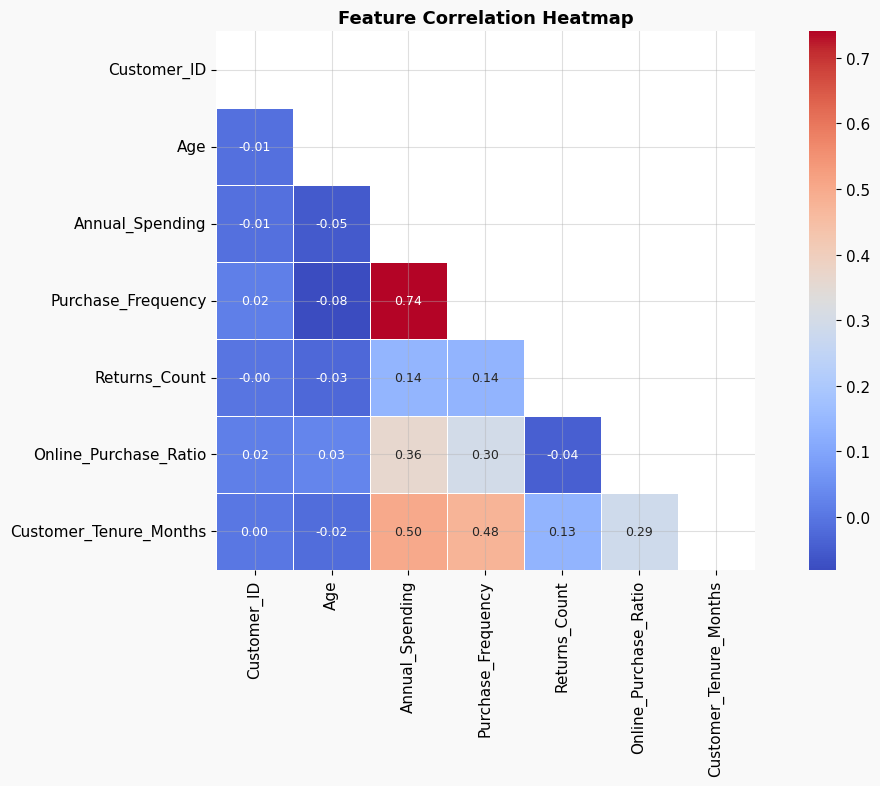

In [60]:
corr = df1.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr,
            annot=True,          # show numbers inside cells
            fmt='.2f',            # round to 2 decimal places
            cmap='coolwarm',     # red=high, blue=low correlation
            mask=np.triu(np.ones_like(corr, dtype=bool)),  # hide upper triangle
            square=True,          # equal cell width and height
            linewidths=0.5,        # thin lines between cells
            annot_kws={'size': 9})  # smaller font so numbers fit

plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cluster_plot.png", dpi=100, bbox_inches='tight')
plt.show()



In [14]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = []

for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        
        if pd.notnull(val) and abs(val) > 0.70:
            high_corr.append((col, row, val))


print("Highly correlated feature pairs (|r| > 0.70):")
if high_corr:
    for col,rows, val in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {col} ↔ {rows}:  r = {val:.4f}")
else:
    print("  → None found above threshold")

print()
print("Correlation with Purchase_Frequency:")
print(df1.corr(numeric_only=True)['Purchase_Frequency'].sort_values(ascending=False).round(4))

Highly correlated feature pairs (|r| > 0.70):
  Purchase_Frequency ↔ Annual_Spending:  r = 0.7404

Correlation with Purchase_Frequency:
Purchase_Frequency        1.0000
Annual_Spending           0.7404
Customer_Tenure_Months    0.4767
Online_Purchase_Ratio     0.2965
Returns_Count             0.1357
Customer_ID               0.0162
Age                      -0.0809
Name: Purchase_Frequency, dtype: float64


In [15]:
print(high_corr)

[('Purchase_Frequency', 'Annual_Spending', np.float64(0.7403810760549987))]


In [44]:
# ── Feature Selection ──
df2 = df1[['Annual_Spending', 'Purchase_Frequency']].copy()
df3 = df1[['Annual_Spending', 'Purchase_Frequency']].copy()
print("Features selected for clustering:")
print("   • Annual_Spending   — total yearly purchase value (₹)")
print("   • Purchase_Frequency — number of transactions per year")
print(f"\ndf2 shape: {df2.shape}")
df2.describe()

Features selected for clustering:
   • Annual_Spending   — total yearly purchase value (₹)
   • Purchase_Frequency — number of transactions per year

df2 shape: (850, 2)


,Annual_Spending,Purchase_Frequency
count,850.000000,850.000000
mean,31778.530847,21.116471
std,30414.097236,14.439161
min,190.610000,1.000000
25%,3270.610000,10.000000
50%,27838.900000,17.000000
75%,40366.335000,28.000000
max,133819.710000,72.000000


### scaler = StandardScaler()
X_scaled = scaler.fit_transform(df2)

print("Before Scaling (first 5 rows):")
print(df2.head().to_string(index=False))

print("\nAfter StandardScaler (first 5 rows):")
scaled_df = pd.DataFrame(X_scaled, columns=['Annual_Spending_z', 'Purchase_Frequency_z'])
print(scaled_df.head().round(4).to_string(index=False))

print(f"\nMean  after scaling → Annual_Spending_z: {X_scaled[:,0].mean():.6f}  |  Freq_z: {X_scaled[:,1].mean():.6f}")
print(f"Std   after scaling → Annual_Spending_z: {X_scaled[:,0].std():.6f}  |  Freq_z: {X_scaled[:,1].std():.6f}")

Optimal K: 2


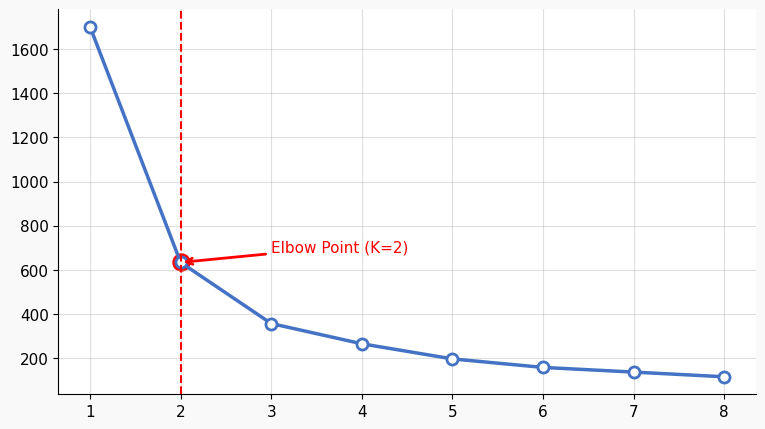

In [63]:
wcss = []
K_range = range(1,9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, wcss, 'o-', color='#4472C4', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)

import numpy as np

K = list(K_range)
wcss_arr = np.array(wcss)

d1 = np.diff(wcss_arr)


d2 = np.diff(d1)

optimal_k = K[np.argmax(d2) + 1]
plt.scatter(optimal_k, wcss[optimal_k-1], color='red', s=150, label=f'K = {optimal_k}')


plt.axvline(x=optimal_k, linestyle='--', color='red')
plt.annotate(
    f'Elbow Point (K={optimal_k})',
    xy=(optimal_k, wcss[optimal_k-1]),
    xytext=(optimal_k+1, wcss[optimal_k-1]+50),
    arrowprops=dict(arrowstyle='->', color='red', lw=2),
    fontsize=11,
    color='red'
)
plt.savefig("cluster_plot3.png", dpi=100, bbox_inches='tight')
print("Optimal K:", optimal_k)

## Step 9 — K-Means Clustering (K = 2)

In [51]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df2['Cluster'] = kmeans.fit_predict(X_scaled)



cluster_means = df2.groupby('Cluster')['Annual_Spending'].mean().sort_values()
rank_map = {old: new for new, old in enumerate(cluster_means.index)}
df2['Cluster'] = df2['Cluster'].map(rank_map)

print(f"\nInertia (WCSS)    : {kmeans.inertia_:.2f}")
sil = silhouette_score(X_scaled, df2['Cluster'])
print(f"Silhouette Score  : {sil:.4f}")
print()
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(X_scaled, df2['Cluster'])
print("Davies-Bouldin Score:", db_score)
print()
print("Cluster counts:")
print(df2['Cluster'].value_counts().sort_index().rename({0:'Cluster 0', 1:'Cluster 1', 2:'Cluster 2'}))
print()
print("Cluster means (original scale):")
print(df2.groupby('Cluster')[['Annual_Spending','Purchase_Frequency']].mean().round(2))


Inertia (WCSS)    : 634.05
Silhouette Score  : 0.6186

Davies-Bouldin Score: 0.6270047491591411

Cluster counts:
Cluster
Cluster 0    671
Cluster 1    179
Name: count, dtype: int64

Cluster means (original scale):
         Annual_Spending  Purchase_Frequency
Cluster                                     
0               19158.09               15.31
1               79087.56               42.90


## Step 10 — Cluster Visualization

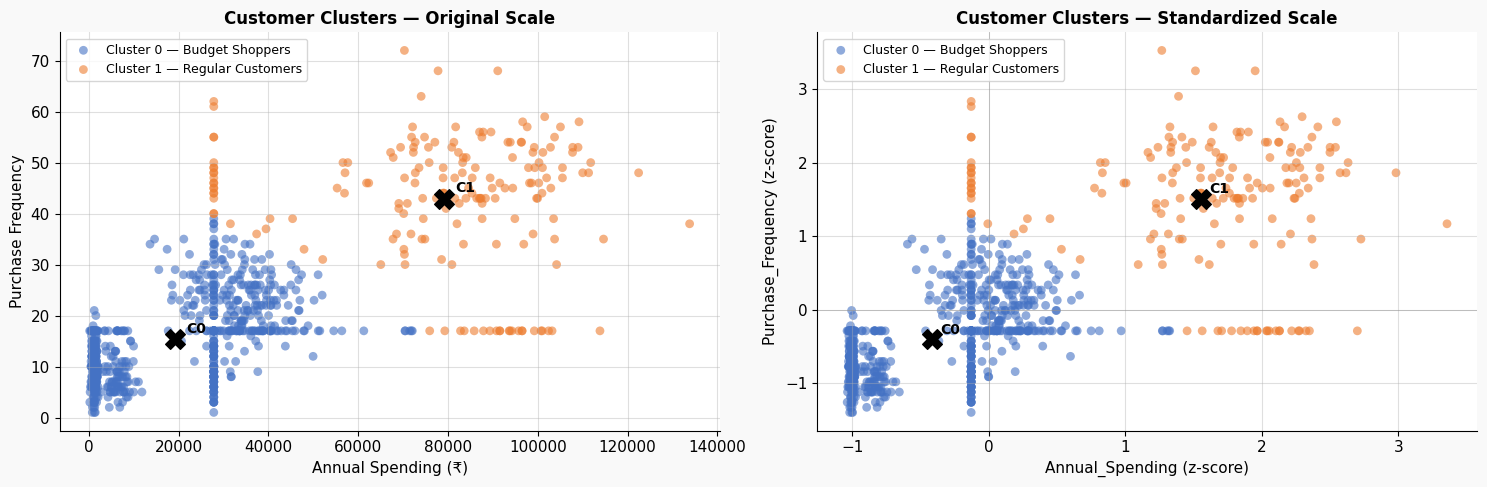

In [64]:
COLORS = ['#4472C4', '#ED7D31']
LABELS = ['Cluster 0 — Budget Shoppers',
          'Cluster 1 — Regular Customers']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


ax = axes[0]
for c in range(2):
    mask = df2['Cluster'] == c
    ax.scatter(df2.loc[mask, 'Annual_Spending'],
               df2.loc[mask, 'Purchase_Frequency'],
               c=COLORS[c], label=LABELS[c], alpha=0.6, s=40, edgecolors='none')

cents_orig = scaler.inverse_transform(kmeans.cluster_centers_)
cents_sorted = cents_orig[np.argsort(cents_orig[:, 0])]  # sort by spending
for i, (cx, cy) in enumerate(cents_sorted):
    ax.scatter(cx, cy, c='black', marker='X', s=200, zorder=10)
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(8, 5), fontweight='bold', fontsize=10)

ax.set_title('Customer Clusters — Original Scale', fontweight='bold', fontsize=12)
ax.set_xlabel('Annual Spending (₹)')
ax.set_ylabel('Purchase Frequency')
ax.legend(fontsize=9, loc='upper left')


ax = axes[1]
for c in range(2):
    mask = df2['Cluster'] == c
    ax.scatter(X_scaled[mask.values, 0], X_scaled[mask.values, 1],
               c=COLORS[c], label=LABELS[c], alpha=0.6, s=40, edgecolors='none')

for i, cent in enumerate(np.sort(kmeans.cluster_centers_, axis=0)):
    ax.scatter(*cent, c='black', marker='X', s=200, zorder=10)
    ax.annotate(f'C{i}', cent, textcoords='offset points',
                xytext=(6, 4), fontweight='bold', fontsize=10)

ax.set_title('Customer Clusters — Standardized Scale', fontweight='bold', fontsize=12)
ax.set_xlabel('Annual_Spending (z-score)')
ax.set_ylabel('Purchase_Frequency (z-score)')
ax.legend(fontsize=9, loc='upper left')
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
plt.savefig("cluster_plot4.png", dpi=100, bbox_inches='tight')
plt.tight_layout()
plt.show()

#Step 11 — Cluster Persona Analysis

In [40]:
df1_clustered = df1.copy().reset_index(drop=True)
df1_clustered['Cluster'] = df2['Cluster'].values

PERSONAS = {
    0: ('Budget Customers', '#4472C4'),
    1: ('Premium Customers', '#ED7D31'),
}

print("=" * 60)
print("CUSTOMER PERSONA PROFILES")
print("=" * 60)

for c, (name, color) in PERSONAS.items():
    grp = df1_clustered[df1_clustered['Cluster'] == c]

    print(f"\n{'─'*60}")
    print(f"  {name}  (Cluster {c})   — {len(grp)} customers ({len(grp)/len(df1_clustered)*100:.1f}%)")
    print(f"{'─'*60}")
    print(f"  Avg Annual Spending  : ₹{grp['Annual_Spending'].mean():,.0f}")
    print(f"  Avg Purchase Freq    : {grp['Purchase_Frequency'].mean():.1f} times/year")
    print(f"  Avg Returns Count    : {grp['Returns_Count'].mean():.2f}")
    print(f"  Avg Online Ratio     : {grp['Online_Purchase_Ratio'].mean():.2%}")
    print(f"  Avg Tenure (months)  : {grp['Customer_Tenure_Months'].mean():.1f}")

CUSTOMER PERSONA PROFILES

────────────────────────────────────────────────────────────
  Budget Customers  (Cluster 0)   — 671 customers (78.9%)
────────────────────────────────────────────────────────────
  Avg Annual Spending  : ₹19,158
  Avg Purchase Freq    : 15.3 times/year
  Avg Returns Count    : 1.45
  Avg Online Ratio     : 42.99%
  Avg Tenure (months)  : 29.1

────────────────────────────────────────────────────────────
  Premium Customers  (Cluster 1)   — 179 customers (21.1%)
────────────────────────────────────────────────────────────
  Avg Annual Spending  : ₹79,088
  Avg Purchase Freq    : 42.9 times/year
  Avg Returns Count    : 1.34
  Avg Online Ratio     : 57.08%
  Avg Tenure (months)  : 46.9
